# 08b — Final BiLSTM/PhoBERT Augmentation and SVM-vs-BiLSTM Failure Analysis

Notebook này **không chạy lại Note 8** và **không tự sinh lại augmented/noisy data của Note 8**.

Nó dùng lại dữ liệu đã có từ Note 8:

- `data/robustness/augmented_train_mixed.csv` hoặc file augmented train tương đương.
- `data/robustness/test_clean.csv`, `test_no_accent.csv`, `test_repeated_char.csv`, `test_special_char.csv`, `test_masked_word.csv`, `test_slang_teencode.csv`, `test_mixed_noise.csv`.
- `outputs/results/note08/` để gom lại metric SVM/XLM-R nếu có.

Notebook 08b chỉ làm phần bổ sung:

- Train BiLSTM original recheck và BiLSTM augmented lâu hơn, có early stopping.
- Train PhoBERT augmented nghiêm túc hơn, có ViTokenizer, validation model selection.
- Evaluate BiLSTM/PhoBERT trên clean + noisy test, before/after normalization.
- Phân tích vì sao BiLSTM kém SVM.
- Gom bảng so sánh augmentation across models: SVM, BiLSTM, PhoBERT, XLM-R.

Output chính nằm ở:

```text
outputs/results/note08b/
outputs/figures/note08b/
outputs/models/note08b/
```


In [3]:
# 1. Install dependencies
# Chạy trong Colab. Không dùng shell magic để notebook vẫn parse được như Python chuẩn.
import sys
import subprocess

packages = [
    "transformers>=4.38.0",
    "accelerate>=0.27.0",
    "pyvi>=0.1.1",
    "joblib>=1.3.0",
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

In [4]:
# 2. Mount Drive and set project paths
from google.colab import drive
from pathlib import Path
import os
import json
import random
import re
import math
import time
import unicodedata
import warnings
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
import joblib

warnings.filterwarnings("ignore")

drive.mount("/content/drive")

PROJECT_ROOT = Path("/content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification")
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT not found: {PROJECT_ROOT}")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
ROBUSTNESS_DIR = DATA_DIR / "robustness"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
RESULTS_DIR = OUTPUTS_DIR / "results" / "note08b"
FIGURES_DIR = OUTPUTS_DIR / "figures" / "note08b"
MODELS_DIR = OUTPUTS_DIR / "models" / "note08b"
CACHE_DIR = OUTPUTS_DIR / "resources" / "note08b"
SRC_DIR = PROJECT_ROOT / "src"
NOTE08_RESULTS_DIR = OUTPUTS_DIR / "results" / "note08"
NOTE08_MODELS_DIR = OUTPUTS_DIR / "models" / "note08"

if not ROBUSTNESS_DIR.exists():
    raise FileNotFoundError(f"Missing Note 8 robustness directory: {ROBUSTNESS_DIR}")

for d in [RESULTS_DIR, FIGURES_DIR, MODELS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Device:", device)
if device.type != "cuda":
    raise RuntimeError("Notebook 08b final cần GPU cho phần PhoBERT. Vào Runtime > Change runtime type > GPU.")

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification
Device: cuda


In [5]:
# 3. Global configuration
LABEL_NAMES = ["CLEAN", "OFFENSIVE", "HATE"]
LABEL_TO_ID = {name: i for i, name in enumerate(LABEL_NAMES)}
ID_TO_LABEL = {i: name for name, i in LABEL_TO_ID.items()}
NUM_LABELS = len(LABEL_NAMES)

TEXT_CANDIDATES = [
    "text", "comment", "content", "sentence", "free_text", "clean_text", "processed_text",
    "comment_text", "review", "input_text", "noisy_text", "normalized_text"
]
LABEL_CANDIDATES = ["label", "label_id", "target", "class", "category", "y", "label_name"]

NOISE_TYPES = [
    "clean",
    "no_accent",
    "repeated_char",
    "special_char",
    "masked_word",
    "slang_teencode",
    "mixed_noise",
]

BILSTM_CONFIG = {
    "max_len": 128,
    "min_freq": 2,
    "max_vocab_size": 60000,
    "embedding_dim": 128,
    "hidden_dim": 256,
    "num_layers": 2,
    "dropout": 0.4,
    "batch_size": 128,
    "epochs": 20,
    "patience": 4,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "grad_clip": 1.0,
}

PHOBERT_CONFIG = {
    "model_name": "vinai/phobert-base",
    "max_length": 128,
    "batch_size": 16,
    "epochs": 3,
    "patience": 2,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "grad_clip": 1.0,
    "use_fp16": True,
}

RUN_CONFIG = {
    "seed": SEED,
    "project_root": str(PROJECT_ROOT),
    "bilstm_config": BILSTM_CONFIG,
    "phobert_config": PHOBERT_CONFIG,
    "labels": LABEL_NAMES,
    "note": "08b final: reuse Note 8 augmented/noisy data only; train BiLSTM and PhoBERT more seriously; analyze SVM vs BiLSTM failures",
}

with open(RESULTS_DIR / "note08b_run_config.json", "w", encoding="utf-8") as f:
    json.dump(RUN_CONFIG, f, ensure_ascii=False, indent=2)

In [6]:
# 4. Data utilities

def find_col(df, candidates, required=True, role="column"):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    for cand in candidates:
        for col in df.columns:
            if cand.lower() in col.lower():
                return col
    if required:
        raise ValueError(f"Cannot find {role}. Columns: {list(df.columns)}")
    return None


def normalize_label_value(x):
    if pd.isna(x):
        return None
    if isinstance(x, (int, np.integer)):
        return ID_TO_LABEL.get(int(x), str(x).upper())
    if isinstance(x, float) and float(x).is_integer():
        return ID_TO_LABEL.get(int(x), str(int(x)))
    s = str(x).strip()
    if re.fullmatch(r"\d+", s):
        return ID_TO_LABEL.get(int(s), s)
    su = s.upper()
    if su in LABEL_TO_ID:
        return su
    if "CLEAN" in su or su in {"0", "NON_TOXIC", "NON-TOXIC", "NORMAL"}:
        return "CLEAN"
    if "OFFENSIVE" in su or "INSULT" in su or "ABUSE" in su:
        return "OFFENSIVE"
    if "HATE" in su or "HATRED" in su:
        return "HATE"
    return su


def standardize_df(df, split_name="data", text_col=None, label_col=None):
    df = df.copy()
    if text_col is None:
        text_col = find_col(df, TEXT_CANDIDATES, required=True, role=f"text column for {split_name}")
    if label_col is None:
        label_col = find_col(df, LABEL_CANDIDATES, required=True, role=f"label column for {split_name}")
    out = pd.DataFrame()
    out["text"] = df[text_col].fillna("").astype(str)
    out["label"] = df[label_col].apply(normalize_label_value)
    unknown = sorted(set(out["label"].dropna()) - set(LABEL_NAMES))
    if unknown:
        raise ValueError(f"Unknown labels in {split_name}: {unknown[:20]}")
    out = out[out["label"].isin(LABEL_NAMES)].reset_index(drop=True)
    out["label_id"] = out["label"].map(LABEL_TO_ID).astype(int)
    out["split"] = split_name
    out["sample_id"] = np.arange(len(out))
    return out


def load_csv_required(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def describe_labels(df, name):
    print(f"\n{name}: {df.shape}")
    print(df["label"].value_counts().reindex(LABEL_NAMES, fill_value=0))

In [7]:
# 5. Load train/val/test from data/processed
train_path = PROCESSED_DIR / "train_processed.csv"
val_path = PROCESSED_DIR / "val_processed.csv"
test_path = PROCESSED_DIR / "test_processed.csv"

train_df = standardize_df(load_csv_required(train_path), "train")
val_df = standardize_df(load_csv_required(val_path), "val")
test_df = standardize_df(load_csv_required(test_path), "test")

describe_labels(train_df, "train")
describe_labels(val_df, "val")
describe_labels(test_df, "test")


train: (24046, 5)
label
CLEAN        19885
OFFENSIVE     1605
HATE          2556
Name: count, dtype: int64

val: (2672, 5)
label
CLEAN        2190
OFFENSIVE     212
HATE          270
Name: count, dtype: int64

test: (6680, 5)
label
CLEAN        5548
OFFENSIVE     444
HATE          688
Name: count, dtype: int64


In [8]:
# 6. Normalization function
# Chỉ dùng để tạo cột after_norm khi file Note 8 chưa có normalized_text.
# Cell này KHÔNG sinh lại noisy/augmented data.
import importlib.util
import re


def fallback_normalize_text(text):
    text = str(text)
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    text = re.sub(r"(?<=\w)[\.\*_\-]+(?=\w)", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


normalization_file = SRC_DIR / "normalization.py"
normalize_text = fallback_normalize_text

if normalization_file.exists():
    spec = importlib.util.spec_from_file_location("project_normalization", normalization_file)
    norm_mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(norm_mod)

    candidate_names = [
        "normalize_text",
        "normalize_for_robustness",
        "normalize_vietnamese_text",
        "normalize_comment",
        "basic_normalize",
    ]

    loaded_name = None
    for name in candidate_names:
        fn = getattr(norm_mod, name, None)
        if callable(fn):
            normalize_text = fn
            loaded_name = name
            break

    if loaded_name is not None:
        print(f"Loaded {loaded_name} from {normalization_file}")
    else:
        available = [name for name in dir(norm_mod) if callable(getattr(norm_mod, name, None)) and not name.startswith("_")]
        print("Found normalization.py but no compatible normalize function.")
        print("Available callable names:", available[:30])
        print("Using fallback_normalize_text instead.")
else:
    print("normalization.py not found. Using fallback_normalize_text.")

_probe = "đồ nguuuu *** vl"
print("Normalization sanity check:", _probe, "->", normalize_text(_probe))


Loaded normalize_comment from /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/src/normalization.py
Normalization sanity check: đồ nguuuu *** vl -> đồ ngu ** vl


In [9]:
# 7. Load augmented train set created by Note 8
# Notebook này KHÔNG tự tạo augmented data mới.
# Nó chỉ đọc file augmentation đã sinh ở Note 8. Nếu không có thì dừng rõ ràng.

NOTE08_AUGMENTED_TRAIN_CANDIDATES = [
    ROBUSTNESS_DIR / "augmented_train_mixed.csv",
    ROBUSTNESS_DIR / "controlled_augmented_train_mixed.csv",
    ROBUSTNESS_DIR / "train_augmented_mixed.csv",
    ROBUSTNESS_DIR / "augmented_train.csv",
]

note08_aug_path = next((p for p in NOTE08_AUGMENTED_TRAIN_CANDIDATES if p.exists()), None)
if note08_aug_path is None:
    msg = "\n".join(str(p) for p in NOTE08_AUGMENTED_TRAIN_CANDIDATES)
    raise FileNotFoundError(
        "Không tìm thấy augmented train file từ Note 8 trong data/robustness. "
        "Chạy xong Note 8 trước hoặc kiểm tra tên file. Các path đã kiểm tra:\n" + msg
    )

raw_aug = pd.read_csv(note08_aug_path)
print("Loaded Note 8 augmented train:", note08_aug_path)
print("Raw shape:", raw_aug.shape)
print("Raw columns:", list(raw_aug.columns))

text_col = find_col(raw_aug, TEXT_CANDIDATES, required=True, role="text column in Note 8 augmented train")
label_col = find_col(raw_aug, LABEL_CANDIDATES, required=True, role="label column in Note 8 augmented train")

aug_tmp = pd.DataFrame()
aug_tmp["text"] = raw_aug[text_col].fillna("").astype(str)
aug_tmp["label"] = raw_aug[label_col].apply(normalize_label_value)
aug_tmp["source"] = raw_aug["source"].fillna("note08_augmented").astype(str).values if "source" in raw_aug.columns else "note08_augmented"
aug_tmp["original_index"] = raw_aug["original_index"].values if "original_index" in raw_aug.columns else -1

invalid_labels = sorted(set(aug_tmp["label"].dropna()) - set(LABEL_NAMES))
if invalid_labels:
    print("Warning: dropping augmented rows with unknown labels:", invalid_labels[:20])

aug_std = aug_tmp[aug_tmp["label"].isin(LABEL_NAMES)].reset_index(drop=True)
aug_std["label_id"] = aug_std["label"].map(LABEL_TO_ID).astype(int)

# Nếu file Note 8 chỉ chứa các dòng augmented, ghép thêm train gốc.
# Đây không phải sinh augmentation mới; chỉ đảm bảo train augmented có cả original + augmented.
train_text_set_sample = set(train_df["text"].head(min(len(train_df), 5000)).astype(str).tolist())
raw_text_sample = aug_std["text"].head(min(len(aug_std), 5000)).astype(str).tolist()
original_overlap_ratio = np.mean([t in train_text_set_sample for t in raw_text_sample]) if raw_text_sample else 0.0
has_original_source = aug_std["source"].str.lower().str.contains("original").any()
looks_like_combined = has_original_source or len(aug_std) >= int(1.5 * len(train_df)) or original_overlap_ratio > 0.20

if looks_like_combined:
    reused_augmented_train_df = aug_std.copy()
    if not has_original_source:
        reused_augmented_train_df["source"] = reused_augmented_train_df["source"].replace("note08_augmented", "note08_augmented_or_combined")
    print("Using Note 8 augmented file as combined training data.")
else:
    orig = train_df[["text", "label", "label_id"]].copy()
    orig["source"] = "original_from_processed_train"
    orig["original_index"] = np.arange(len(orig))
    reused_augmented_train_df = pd.concat([orig, aug_std], ignore_index=True)
    print("Note 8 augmented file looks like augmented-only rows. Added original train rows for training.")

reused_augmented_train_df["split"] = "train_note08_augmented_reused"
reused_augmented_train_df = reused_augmented_train_df.drop_duplicates(subset=["text", "label_id"]).reset_index(drop=True)

# Lưu index chuẩn hóa vào results để audit; không ghi augmented data mới vào data/robustness.
reused_aug_index_path = RESULTS_DIR / "reused_note08_augmented_train_index.csv"
reused_augmented_train_df.to_csv(reused_aug_index_path, index=False)

print("Saved audit copy:", reused_aug_index_path)
print("Reused augmented training rows for 08b:", len(reused_augmented_train_df))
print(reused_augmented_train_df["source"].value_counts().head(20))
print(reused_augmented_train_df["label"].value_counts().reindex(LABEL_NAMES, fill_value=0))


Loaded Note 8 augmented train: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/data/robustness/augmented_train_mixed.csv
Raw shape: (168322, 4)
Raw columns: ['text', 'label_id', 'source', 'noise_type']
Using Note 8 augmented file as combined training data.
Saved audit copy: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note08b/reused_note08_augmented_train_index.csv
Reused augmented training rows for 08b: 134847
source
augmented    112157
original      22690
Name: count, dtype: int64
label
CLEAN        110222
OFFENSIVE      9272
HATE          15353
Name: count, dtype: int64


In [10]:
# 8. Load robustness test sets created by Note 8
# Notebook này KHÔNG tự sinh noisy test mới. Nếu thiếu file Note 8 thì dừng rõ ràng.

missing_test_files = [ROBUSTNESS_DIR / f"test_{nt}.csv" for nt in NOISE_TYPES if not (ROBUSTNESS_DIR / f"test_{nt}.csv").exists()]
if missing_test_files:
    msg = "\n".join(str(p) for p in missing_test_files)
    raise FileNotFoundError(
        "Thiếu robustness/noisy test file từ Note 8. Chạy Note 8 trước hoặc kiểm tra data/robustness. Missing:\n" + msg
    )


def load_one_robust_test(noise_type):
    path = ROBUSTNESS_DIR / f"test_{noise_type}.csv"
    raw = pd.read_csv(path)
    before_col = None
    for c in ["noisy_text", "text", "comment", "content", "clean_text", "processed_text"]:
        if c in raw.columns:
            before_col = c
            break
    if before_col is None:
        before_col = find_col(raw, TEXT_CANDIDATES, required=True, role=f"robustness text for {noise_type}")

    label_col = find_col(raw, LABEL_CANDIDATES, required=False, role=f"label for {noise_type}")
    out = pd.DataFrame()
    out["sample_id"] = raw["sample_id"].values if "sample_id" in raw.columns else np.arange(len(raw))
    out["text_before_norm"] = raw[before_col].fillna("").astype(str)

    if "normalized_text" in raw.columns:
        out["text_after_norm"] = raw["normalized_text"].fillna("").astype(str)
    else:
        out["text_after_norm"] = out["text_before_norm"].apply(normalize_text)

    if label_col is not None:
        out["label"] = raw[label_col].apply(normalize_label_value)
        out = out[out["label"].isin(LABEL_NAMES)].reset_index(drop=True)
        out["label_id"] = out["label"].map(LABEL_TO_ID).astype(int)
    else:
        out = out.merge(test_df[["sample_id", "label", "label_id"]], on="sample_id", how="left")

    out["noise_type"] = noise_type
    return out[["sample_id", "noise_type", "text_before_norm", "text_after_norm", "label", "label_id"]]


robust_tests = []
for nt in NOISE_TYPES:
    d = load_one_robust_test(nt)
    robust_tests.append(d)
    print(nt, d.shape)

robust_test_df = pd.concat(robust_tests, ignore_index=True)
robust_test_df.to_csv(RESULTS_DIR / "robustness_test_index_note08b.csv", index=False)
print("Combined robustness test rows:", robust_test_df.shape)


clean (6680, 6)
no_accent (6680, 6)
repeated_char (6680, 6)
special_char (6680, 6)
masked_word (6680, 6)
slang_teencode (6680, 6)
mixed_noise (6680, 6)
Combined robustness test rows: (46760, 6)


In [11]:
# 8b. Sanity check: Note 8b chỉ reuse dữ liệu Note 8
required_note08_inputs = [
    note08_aug_path,
    *[ROBUSTNESS_DIR / f"test_{nt}.csv" for nt in NOISE_TYPES],
]
check_inputs = pd.DataFrame({
    "path": [str(p) for p in required_note08_inputs],
    "exists": [Path(p).exists() for p in required_note08_inputs],
})
check_inputs.to_csv(RESULTS_DIR / "note08b_reused_note08_inputs_check.csv", index=False)
print(check_inputs)

if not check_inputs["exists"].all():
    missing = check_inputs.loc[~check_inputs["exists"], "path"].tolist()
    raise FileNotFoundError("Missing required Note 8 inputs:\n" + "\n".join(missing))

print("OK: Note 8b không sinh lại augmentation/noisy data; chỉ đọc dữ liệu đã có từ Note 8.")

                                                path  exists
0  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
1  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
2  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
3  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
4  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
5  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
6  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
7  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
OK: Note 8b không sinh lại augmentation/noisy data; chỉ đọc dữ liệu đã có từ Note 8.


In [12]:
# 9. Metric helpers

def safe_div(a, b):
    return float(a) / float(b) if b else 0.0


def metric_dict(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_LABELS)), zero_division=0
    )
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_p,
        "weighted_recall": weighted_r,
        "weighted_f1": weighted_f1,
    }
    for i, name in ID_TO_LABEL.items():
        out[f"{name.lower()}_precision"] = precision[i]
        out[f"{name.lower()}_recall"] = recall[i]
        out[f"{name.lower()}_f1"] = f1[i]
        out[f"{name.lower()}_support"] = int(support[i])
    return out


def save_classification_report(y_true, y_pred, path):
    rep = classification_report(
        y_true, y_pred, labels=list(range(NUM_LABELS)), target_names=LABEL_NAMES,
        output_dict=True, zero_division=0
    )
    pd.DataFrame(rep).T.to_csv(path)

## BiLSTM: train lại nghiêm túc hơn

BiLSTM final không normalize ngầm trong tokenizer, để before/after normalization khác nhau khi evaluate robustness.

In [13]:
# 10. BiLSTM tokenizer, vocab, dataset, model
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"


def tokenize_bilstm(text):
    text = str(text).lower()
    # Token cơ bản, giữ dấu tiếng Việt, không gọi normalize_text để đánh giá robustness rõ hơn.
    return re.findall(r"\w+|[^\w\s]", text, flags=re.UNICODE)


def build_vocab(texts, min_freq=2, max_size=60000):
    counter = Counter()
    for text in texts:
        counter.update(tokenize_bilstm(text))
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for tok, freq in counter.most_common():
        if freq < min_freq:
            continue
        if tok in vocab:
            continue
        vocab[tok] = len(vocab)
        if len(vocab) >= max_size:
            break
    return vocab, counter


def encode_text(text, vocab, max_len):
    ids = [vocab.get(tok, vocab[UNK_TOKEN]) for tok in tokenize_bilstm(text)]
    if len(ids) > max_len:
        ids = ids[:max_len]
    att_len = len(ids)
    if len(ids) < max_len:
        ids = ids + [vocab[PAD_TOKEN]] * (max_len - len(ids))
    return ids, att_len


class TextClsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = list(texts)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids, length = encode_text(self.texts[idx], self.vocab, self.max_len)
        return {
            "input_ids": torch.tensor(ids, dtype=torch.long),
            "length": torch.tensor(length, dtype=torch.long),
            "label": torch.tensor(self.labels[idx], dtype=torch.long),
        }


class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, num_labels, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, input_ids, lengths):
        emb = self.embedding(input_ids)
        lengths_cpu = lengths.detach().cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths_cpu, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        # last forward and backward states
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat([h_forward, h_backward], dim=1)
        h = self.dropout(h)
        return self.classifier(h)

In [14]:
# 11. BiLSTM training/evaluation functions

def make_loaders_for_bilstm(train_data, val_data, vocab, config):
    train_ds = TextClsDataset(train_data["text"], train_data["label_id"], vocab, config["max_len"])
    val_ds = TextClsDataset(val_data["text"], val_data["label_id"], vocab, config["max_len"])
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=config["batch_size"] * 2, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader


def predict_bilstm(model, texts, labels, vocab, config, batch_size=None):
    if batch_size is None:
        batch_size = config["batch_size"] * 2
    ds = TextClsDataset(texts, labels, vocab, config["max_len"])
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    model.eval()
    preds = []
    probs = []
    true = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            logits = model(input_ids, lengths)
            p = torch.softmax(logits, dim=-1)
            preds.extend(torch.argmax(p, dim=-1).detach().cpu().numpy().tolist())
            probs.extend(p.detach().cpu().numpy().tolist())
            true.extend(batch["label"].numpy().tolist())
    return np.asarray(true), np.asarray(preds), np.asarray(probs)


def train_bilstm_model(train_data, val_data, model_tag, config):
    model_dir = MODELS_DIR / model_tag
    model_dir.mkdir(parents=True, exist_ok=True)
    vocab, token_counter = build_vocab(
        train_data["text"].tolist(),
        min_freq=config["min_freq"],
        max_size=config["max_vocab_size"],
    )
    train_loader, val_loader = make_loaders_for_bilstm(train_data, val_data, vocab, config)

    model = BiLSTMClassifier(
        vocab_size=len(vocab),
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        num_layers=config["num_layers"],
        num_labels=NUM_LABELS,
        dropout=config["dropout"],
        pad_idx=vocab[PAD_TOKEN],
    ).to(device)

    classes = np.arange(NUM_LABELS)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label_id"].values)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    best_f1 = -1.0
    best_epoch = -1
    no_improve = 0
    history = []
    best_path = model_dir / "bilstm_best.pt"

    for epoch in range(1, config["epochs"] + 1):
        model.train()
        total_loss = 0.0
        n_items = 0
        start = time.time()
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            input_ids = batch["input_ids"].to(device)
            lengths = batch["length"].to(device)
            labels = batch["label"].to(device)
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), config["grad_clip"])
            optimizer.step()
            total_loss += float(loss.item()) * labels.size(0)
            n_items += labels.size(0)

        y_true, y_pred, _ = predict_bilstm(model, val_data["text"], val_data["label_id"], vocab, config)
        metrics = metric_dict(y_true, y_pred)
        train_loss = total_loss / max(1, n_items)
        row = {
            "model_tag": model_tag,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_macro_f1": metrics["macro_f1"],
            "val_accuracy": metrics["accuracy"],
            "elapsed_sec": time.time() - start,
        }
        history.append(row)
        print(f"[{model_tag}] epoch {epoch:02d} loss={train_loss:.4f} val_macro_f1={metrics['macro_f1']:.4f} val_acc={metrics['accuracy']:.4f}")

        if metrics["macro_f1"] > best_f1:
            best_f1 = metrics["macro_f1"]
            best_epoch = epoch
            no_improve = 0
            torch.save({
                "state_dict": model.state_dict(),
                "vocab": vocab,
                "config": config,
                "label_to_id": LABEL_TO_ID,
                "id_to_label": ID_TO_LABEL,
                "best_epoch": best_epoch,
                "best_val_macro_f1": best_f1,
            }, best_path)
            with open(model_dir / "vocab.json", "w", encoding="utf-8") as f:
                json.dump(vocab, f, ensure_ascii=False)
        else:
            no_improve += 1
            if no_improve >= config["patience"]:
                print(f"Early stopping at epoch {epoch}. Best epoch {best_epoch}, best val macro F1 {best_f1:.4f}")
                break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(RESULTS_DIR / f"{model_tag}_training_log.csv", index=False)

    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint["state_dict"])
    return {"model": model, "vocab": checkpoint["vocab"], "config": config, "model_tag": model_tag, "best_path": str(best_path), "history": hist_df}

In [15]:
# 12. Train BiLSTM original recheck and augmented
# Original recheck giúp so sánh cùng code/evaluation với augmented.
bilstm_original_bundle = train_bilstm_model(
    train_df[["text", "label_id"]].copy(),
    val_df[["text", "label_id"]].copy(),
    model_tag="bilstm_original_recheck",
    config=BILSTM_CONFIG,
)

bilstm_augmented_bundle = train_bilstm_model(
    reused_augmented_train_df[["text", "label_id"]].copy(),
    val_df[["text", "label_id"]].copy(),
    model_tag="bilstm_augmented_mixed",
    config=BILSTM_CONFIG,
)

[bilstm_original_recheck] epoch 01 loss=0.9556 val_macro_f1=0.4982 val_acc=0.6751
[bilstm_original_recheck] epoch 02 loss=0.7681 val_macro_f1=0.5616 val_acc=0.7429
[bilstm_original_recheck] epoch 03 loss=0.6140 val_macro_f1=0.5585 val_acc=0.7317
[bilstm_original_recheck] epoch 04 loss=0.4561 val_macro_f1=0.5635 val_acc=0.7575
[bilstm_original_recheck] epoch 05 loss=0.3126 val_macro_f1=0.5733 val_acc=0.7717
[bilstm_original_recheck] epoch 06 loss=0.2153 val_macro_f1=0.5821 val_acc=0.7784
[bilstm_original_recheck] epoch 07 loss=0.1559 val_macro_f1=0.5806 val_acc=0.7833
[bilstm_original_recheck] epoch 08 loss=0.1213 val_macro_f1=0.6204 val_acc=0.8249
[bilstm_original_recheck] epoch 09 loss=0.1002 val_macro_f1=0.6020 val_acc=0.8046
[bilstm_original_recheck] epoch 10 loss=0.0751 val_macro_f1=0.6126 val_acc=0.8275
[bilstm_original_recheck] epoch 11 loss=0.0658 val_macro_f1=0.6136 val_acc=0.8297
[bilstm_original_recheck] epoch 12 loss=0.0550 val_macro_f1=0.6108 val_acc=0.8192
Early stopping a

In [16]:
# 13. Evaluate BiLSTM original/augmented on robustness tests
bilstm_metric_rows = []
bilstm_pred_rows = []

for bundle in [bilstm_original_bundle, bilstm_augmented_bundle]:
    model = bundle["model"]
    vocab = bundle["vocab"]
    config = bundle["config"]
    model_tag = bundle["model_tag"]
    for noise_type in NOISE_TYPES:
        sub = robust_test_df[robust_test_df["noise_type"] == noise_type].copy().sort_values("sample_id")
        for stage, text_col in [("before_norm", "text_before_norm"), ("after_norm", "text_after_norm")]:
            y_true, y_pred, prob = predict_bilstm(model, sub[text_col], sub["label_id"], vocab, config)
            m = metric_dict(y_true, y_pred)
            m.update({"model": "BiLSTM", "train_setting": model_tag, "noise_type": noise_type, "norm_stage": stage})
            bilstm_metric_rows.append(m)
            tmp = pd.DataFrame({
                "sample_id": sub["sample_id"].values,
                "model": "BiLSTM",
                "train_setting": model_tag,
                "noise_type": noise_type,
                "norm_stage": stage,
                "text": sub[text_col].values,
                "true_label": [ID_TO_LABEL[i] for i in y_true],
                "pred_label": [ID_TO_LABEL[i] for i in y_pred],
                "true_label_id": y_true,
                "pred_label_id": y_pred,
                "prob_clean": prob[:, 0],
                "prob_offensive": prob[:, 1],
                "prob_hate": prob[:, 2],
            })
            bilstm_pred_rows.append(tmp)

bilstm_metrics_df = pd.DataFrame(bilstm_metric_rows)
bilstm_predictions_df = pd.concat(bilstm_pred_rows, ignore_index=True)

bilstm_metrics_df.to_csv(RESULTS_DIR / "bilstm_robustness_metrics.csv", index=False)
bilstm_predictions_df.to_csv(RESULTS_DIR / "bilstm_robustness_predictions.csv", index=False)

clean_bilstm = bilstm_metrics_df[(bilstm_metrics_df["noise_type"] == "clean") & (bilstm_metrics_df["norm_stage"] == "before_norm")]
print(clean_bilstm[["model", "train_setting", "macro_f1", "accuracy"]])

     model            train_setting  macro_f1  accuracy
0   BiLSTM  bilstm_original_recheck  0.596352  0.825150
14  BiLSTM   bilstm_augmented_mixed  0.601021  0.843114


## SVM vs BiLSTM failure analysis

Phần này trả lời trực tiếp vì sao BiLSTM tệ hơn SVM: so sánh từng sample trên clean test.

In [17]:
# 14. Get SVM predictions on clean test

def load_or_train_svm():
    # Ưu tiên artifact Note 8 nếu có.
    vectorizer_candidates = [
        NOTE08_MODELS_DIR / "tfidf_original_note08.joblib",
        OUTPUTS_DIR / "models" / "tfidf_vectorizer.joblib",
        OUTPUTS_DIR / "models" / "tfidf_vectorizer.pkl",
    ]
    model_candidates = [
        NOTE08_MODELS_DIR / "svm_original_note08.joblib",
        OUTPUTS_DIR / "models" / "svm_model.joblib",
        OUTPUTS_DIR / "models" / "svm_model.pkl",
    ]
    vec_path = next((p for p in vectorizer_candidates if p.exists()), None)
    svm_path = next((p for p in model_candidates if p.exists()), None)
    if vec_path is not None and svm_path is not None:
        print("Loaded SVM artifacts:", vec_path, svm_path)
        vectorizer = joblib.load(vec_path)
        svm_model = joblib.load(svm_path)
        return ("loaded_artifact", vectorizer, svm_model)

    print("SVM artifact not found. Training fallback LinearSVC for failure analysis.")
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=100000, sublinear_tf=True)
    X_train = vectorizer.fit_transform(train_df["text"])
    svm_model = LinearSVC(class_weight="balanced", random_state=SEED)
    svm_model.fit(X_train, train_df["label_id"])
    joblib.dump(vectorizer, MODELS_DIR / "svm_failure_analysis_tfidf.joblib")
    joblib.dump(svm_model, MODELS_DIR / "svm_failure_analysis_linearsvc.joblib")
    return ("trained_fallback", vectorizer, svm_model)

svm_source, svm_vectorizer, svm_model = load_or_train_svm()
clean_sub = robust_test_df[robust_test_df["noise_type"] == "clean"].copy().sort_values("sample_id")
X_clean = svm_vectorizer.transform(clean_sub["text_before_norm"])
svm_pred = svm_model.predict(X_clean).astype(int)

svm_pred_df = pd.DataFrame({
    "sample_id": clean_sub["sample_id"].values,
    "text": clean_sub["text_before_norm"].values,
    "true_label_id": clean_sub["label_id"].values,
    "true_label": clean_sub["label"].values,
    "svm_pred_id": svm_pred,
    "svm_pred_label": [ID_TO_LABEL[i] for i in svm_pred],
    "svm_source": svm_source,
})
svm_pred_df.to_csv(RESULTS_DIR / "svm_clean_predictions_for_failure_analysis.csv", index=False)

print(metric_dict(svm_pred_df["true_label_id"], svm_pred_df["svm_pred_id"]))

Loaded SVM artifacts: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08/tfidf_original_note08.joblib /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08/svm_original_note08.joblib
{'accuracy': 0.865568862275449, 'macro_precision': 0.6573112382529305, 'macro_recall': 0.6225722922835648, 'macro_f1': 0.6369848714692066, 'weighted_precision': 0.8580425970979288, 'weighted_recall': 0.865568862275449, 'weighted_f1': 0.8611422813237207, 'clean_precision': np.float64(0.924408336276934), 'clean_recall': np.float64(0.9434030281182408), 'clean_f1': np.float64(0.9338090990187333), 'clean_support': 5548, 'offensive_precision': np.float64(0.4819277108433735), 'offensive_recall': np.float64(0.36036036036036034), 'offensive_f1': np.float64(0.41237113402061853), 'offensive_support': 444, 'hate_precision': np.float64(0.565597667638484), 'hate_recall': np.float64(0.563953488372093), 'hate_f1': np.float64(0.5647743813682679), 'h

In [18]:
# 15. Compare SVM vs BiLSTM original recheck
bilstm_clean_pred = bilstm_predictions_df[
    (bilstm_predictions_df["train_setting"] == "bilstm_original_recheck")
    & (bilstm_predictions_df["noise_type"] == "clean")
    & (bilstm_predictions_df["norm_stage"] == "before_norm")
].copy()

cmp_df = svm_pred_df.merge(
    bilstm_clean_pred[["sample_id", "pred_label_id", "pred_label", "prob_clean", "prob_offensive", "prob_hate"]].rename(columns={
        "pred_label_id": "bilstm_pred_id",
        "pred_label": "bilstm_pred_label",
    }),
    on="sample_id",
    how="inner",
)

cmp_df["svm_correct"] = cmp_df["svm_pred_id"] == cmp_df["true_label_id"]
cmp_df["bilstm_correct"] = cmp_df["bilstm_pred_id"] == cmp_df["true_label_id"]

def assign_group(row):
    if row["svm_correct"] and row["bilstm_correct"]:
        return "both_right"
    if row["svm_correct"] and not row["bilstm_correct"]:
        return "svm_right_bilstm_wrong"
    if not row["svm_correct"] and row["bilstm_correct"]:
        return "bilstm_right_svm_wrong"
    return "both_wrong"

cmp_df["comparison_group"] = cmp_df.apply(assign_group, axis=1)
cmp_df["text_len_chars"] = cmp_df["text"].astype(str).str.len()
cmp_df["text_len_tokens"] = cmp_df["text"].apply(lambda x: len(tokenize_bilstm(x)))

# OOV proxy theo vocab của BiLSTM original
orig_vocab = bilstm_original_bundle["vocab"]

def oov_rate(text):
    toks = tokenize_bilstm(text)
    if not toks:
        return 0.0
    return sum(1 for t in toks if t not in orig_vocab) / len(toks)

cmp_df["bilstm_oov_rate"] = cmp_df["text"].apply(oov_rate)

# Toxic keyword count từ output Note 6 nếu có, fallback bằng list ngắn.
def load_toxic_terms():
    candidates = [
        OUTPUTS_DIR / "resources" / "toxic_phrases_candidates_train.csv",
        OUTPUTS_DIR / "resources" / "toxic_phrases_candidates.csv",
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p)
            phrase_col = find_col(df, ["phrase", "toxic_phrase", "span_text", "text", "term", "keyword"], required=False)
            if phrase_col is not None:
                terms = df[phrase_col].dropna().astype(str).str.lower().unique().tolist()
                return [t for t in terms if 2 <= len(t) <= 40][:1000]
    return ["ngu", "đần", "điên", "cút", "óc", "chó", "lồn", "địt", "dm", "vl", "vcl", "rác", "súc vật"]

toxic_terms = load_toxic_terms()

def toxic_keyword_count(text):
    s = str(text).lower()
    return sum(1 for term in toxic_terms if term in s)

cmp_df["toxic_keyword_count"] = cmp_df["text"].apply(toxic_keyword_count)

cmp_path = RESULTS_DIR / "svm_vs_bilstm_error_comparison.csv"
cmp_df.to_csv(cmp_path, index=False)

summary = cmp_df.groupby(["comparison_group", "true_label"], dropna=False).size().reset_index(name="count")
summary.to_csv(RESULTS_DIR / "svm_vs_bilstm_group_by_class.csv", index=False)

failure_summary = cmp_df.groupby("comparison_group").agg(
    count=("sample_id", "count"),
    mean_len_chars=("text_len_chars", "mean"),
    mean_len_tokens=("text_len_tokens", "mean"),
    mean_oov_rate=("bilstm_oov_rate", "mean"),
    mean_toxic_keyword_count=("toxic_keyword_count", "mean"),
).reset_index()
failure_summary.to_csv(RESULTS_DIR / "bilstm_failure_summary.csv", index=False)

examples = cmp_df[cmp_df["comparison_group"].isin(["svm_right_bilstm_wrong", "bilstm_right_svm_wrong", "both_wrong"])].copy()
examples = examples.sort_values(["comparison_group", "true_label", "text_len_tokens"]).groupby("comparison_group").head(80)
examples.to_csv(RESULTS_DIR / "bilstm_failure_examples.csv", index=False)

print("Saved:", cmp_path)
print(failure_summary)

Saved: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note08b/svm_vs_bilstm_error_comparison.csv
         comparison_group  count  mean_len_chars  mean_len_tokens  \
0  bilstm_right_svm_wrong    243       71.074074        19.748971   
1              both_right   5269       43.074397        11.875878   
2              both_wrong    655       63.186260        17.509924   
3  svm_right_bilstm_wrong    513       67.775828        19.325536   

   mean_oov_rate  mean_toxic_keyword_count  
0       0.017769                  3.559671  
1       0.032675                  1.736762  
2       0.034567                  3.509924  
3       0.027770                  3.204678  


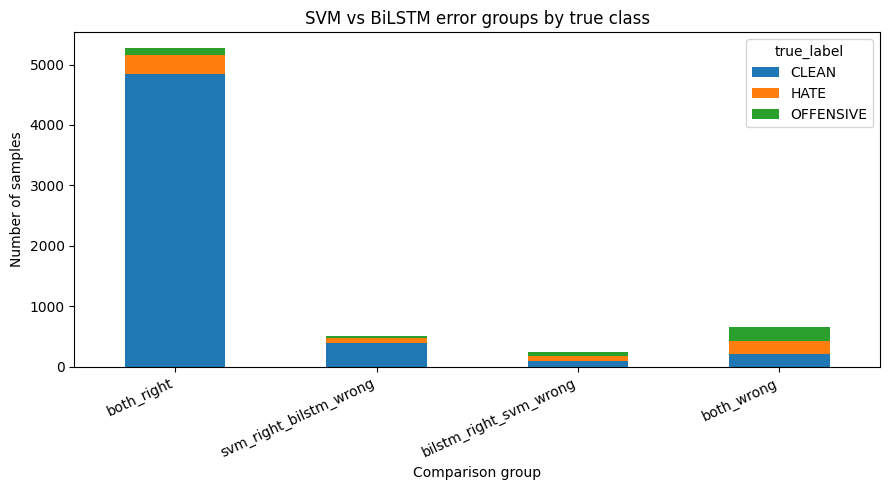

<Figure size 900x500 with 0 Axes>

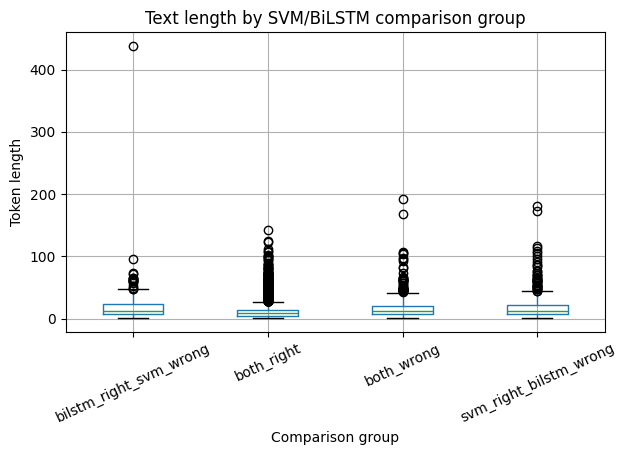

In [19]:
# 16. Failure analysis figures
plt.figure(figsize=(9, 5))
plot_df = cmp_df.groupby(["comparison_group", "true_label"]).size().reset_index(name="count")
pivot = plot_df.pivot(index="comparison_group", columns="true_label", values="count").reindex(
    ["both_right", "svm_right_bilstm_wrong", "bilstm_right_svm_wrong", "both_wrong"]
).fillna(0)
pivot.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("SVM vs BiLSTM error groups by true class")
plt.xlabel("Comparison group")
plt.ylabel("Number of samples")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "svm_bilstm_error_by_group.png", dpi=180)
plt.show()

plt.figure(figsize=(9, 5))
cmp_df.boxplot(column="text_len_tokens", by="comparison_group", rot=25)
plt.title("Text length by SVM/BiLSTM comparison group")
plt.suptitle("")
plt.xlabel("Comparison group")
plt.ylabel("Token length")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "svm_bilstm_error_by_text_length.png", dpi=180)
plt.show()

## PhoBERT augmented

Khác bản nhanh: phần này dùng ViTokenizer, train nhiều epoch hơn, chọn checkpoint tốt nhất theo validation macro F1.

In [20]:
# 17. PhoBERT imports and segmentation helpers
from pyvi import ViTokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.cuda.amp import autocast, GradScaler

phobert_tokenizer = AutoTokenizer.from_pretrained(PHOBERT_CONFIG["model_name"], use_fast=False)


def segment_vietnamese(text):
    text = str(text)
    if not text.strip():
        return ""
    return ViTokenizer.tokenize(text)


def get_or_create_segmented(df, text_col, cache_path, id_cols=None):
    cache_path = Path(cache_path)
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        if len(cached) == len(df) and "segmented_text" in cached.columns:
            return cached
    out = pd.DataFrame()
    if id_cols:
        for c in id_cols:
            if c in df.columns:
                out[c] = df[c].values
    out["text"] = df[text_col].fillna("").astype(str).values
    out["segmented_text"] = [segment_vietnamese(t) for t in out["text"].tolist()]
    if "label_id" in df.columns:
        out["label_id"] = df["label_id"].values
    if "label" in df.columns:
        out["label"] = df["label"].values
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(cache_path, index=False)
    return out

phobert_train_aug_cache = CACHE_DIR / "phobert_augmented_train_segmented.csv"
phobert_val_cache = CACHE_DIR / "phobert_val_segmented.csv"

phobert_train_aug_df = get_or_create_segmented(
    reused_augmented_train_df[["text", "label", "label_id", "source"]].copy(),
    "text",
    phobert_train_aug_cache,
    id_cols=["source"],
)
phobert_val_df = get_or_create_segmented(
    val_df[["text", "label", "label_id"]].copy(),
    "text",
    phobert_val_cache,
)

print(phobert_train_aug_df.shape, phobert_val_df.shape)
print(phobert_train_aug_df.head(2))

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

(134847, 5) (2672, 4)
     source                                               text  \
0  original  Em được làm fan cứng luôn rồi nè ❤️ reaction q...   
1  original  Đúng là bọn mắt híp lò xo thụt :))) bên việt n...   

                                      segmented_text  label_id  label  
0  Em được làm fan cứng luôn rồi nè ❤ ️ reaction ...         0  CLEAN  
1  Đúng là bọn mắt híp lò_xo thụt : ) ) ) bên việ...         2   HATE  


In [21]:
# 18. PhoBERT dataset and training functions
class PhoBERTDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return self.texts[idx], int(self.labels[idx])


def phobert_collate_fn(batch):
    texts, labels = zip(*batch)
    enc = phobert_tokenizer(
        list(texts),
        truncation=True,
        padding=True,
        max_length=PHOBERT_CONFIG["max_length"],
        return_tensors="pt",
    )
    enc["labels"] = torch.tensor(labels, dtype=torch.long)
    return enc


def make_phobert_loader(df, batch_size, shuffle):
    ds = PhoBERTDataset(df["segmented_text"].fillna(""), df["label_id"])
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, collate_fn=phobert_collate_fn, num_workers=2, pin_memory=True)


def evaluate_phobert_model(model, eval_df, batch_size=None):
    if batch_size is None:
        batch_size = PHOBERT_CONFIG["batch_size"] * 2
    loader = make_phobert_loader(eval_df, batch_size=batch_size, shuffle=False)
    model.eval()
    all_true = []
    all_pred = []
    all_probs = []
    with torch.no_grad():
        for batch in loader:
            labels = batch.pop("labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            all_true.extend(labels.detach().cpu().numpy().tolist())
            all_pred.extend(preds.detach().cpu().numpy().tolist())
            all_probs.extend(probs.detach().cpu().numpy().tolist())
    return np.asarray(all_true), np.asarray(all_pred), np.asarray(all_probs)


def train_phobert_augmented(train_data, val_data):
    model_tag = "phobert_augmented_mixed"
    model_dir = MODELS_DIR / model_tag
    model_dir.mkdir(parents=True, exist_ok=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        PHOBERT_CONFIG["model_name"],
        num_labels=NUM_LABELS,
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID,
    ).to(device)

    train_loader = make_phobert_loader(train_data, PHOBERT_CONFIG["batch_size"], shuffle=True)
    val_loader = make_phobert_loader(val_data, PHOBERT_CONFIG["batch_size"] * 2, shuffle=False)

    classes = np.arange(NUM_LABELS)
    class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label_id"].values)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    no_decay = ["bias", "LayerNorm.weight"]
    optimizer_grouped_parameters = [
        {
            "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            "weight_decay": PHOBERT_CONFIG["weight_decay"],
        },
        {
            "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            "weight_decay": 0.0,
        },
    ]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=PHOBERT_CONFIG["lr"])

    total_steps = len(train_loader) * PHOBERT_CONFIG["epochs"]
    warmup_steps = int(total_steps * PHOBERT_CONFIG["warmup_ratio"])
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    scaler = GradScaler(enabled=PHOBERT_CONFIG["use_fp16"] and device.type == "cuda")

    best_f1 = -1.0
    best_epoch = -1
    no_improve = 0
    history = []

    for epoch in range(1, PHOBERT_CONFIG["epochs"] + 1):
        model.train()
        total_loss = 0.0
        n_items = 0
        start = time.time()
        for batch in train_loader:
            labels = batch.pop("labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with autocast(enabled=PHOBERT_CONFIG["use_fp16"] and device.type == "cuda"):
                outputs = model(**batch)
                loss = criterion(outputs.logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), PHOBERT_CONFIG["grad_clip"])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += float(loss.item()) * labels.size(0)
            n_items += labels.size(0)

        y_true, y_pred, _ = evaluate_phobert_model(model, val_data)
        metrics = metric_dict(y_true, y_pred)
        train_loss = total_loss / max(1, n_items)
        row = {
            "model_tag": model_tag,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_macro_f1": metrics["macro_f1"],
            "val_accuracy": metrics["accuracy"],
            "elapsed_sec": time.time() - start,
        }
        history.append(row)
        print(f"[PhoBERT augmented] epoch {epoch:02d} loss={train_loss:.4f} val_macro_f1={metrics['macro_f1']:.4f} val_acc={metrics['accuracy']:.4f}")

        if metrics["macro_f1"] > best_f1:
            best_f1 = metrics["macro_f1"]
            best_epoch = epoch
            no_improve = 0
            model.save_pretrained(model_dir)
            phobert_tokenizer.save_pretrained(model_dir)
            with open(model_dir / "training_meta.json", "w", encoding="utf-8") as f:
                json.dump({"best_epoch": best_epoch, "best_val_macro_f1": best_f1, "config": PHOBERT_CONFIG}, f, ensure_ascii=False, indent=2)
        else:
            no_improve += 1
            if no_improve >= PHOBERT_CONFIG["patience"]:
                print(f"Early stopping at epoch {epoch}. Best epoch {best_epoch}, best val macro F1 {best_f1:.4f}")
                break

    hist_df = pd.DataFrame(history)
    hist_df.to_csv(RESULTS_DIR / "phobert_augmented_training_log.csv", index=False)
    best_model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
    return best_model, hist_df, str(model_dir)

In [22]:
# 19. Train PhoBERT augmented
phobert_augmented_model, phobert_history_df, phobert_model_dir = train_phobert_augmented(
    phobert_train_aug_df,
    phobert_val_df,
)
print("Best PhoBERT augmented model saved to:", phobert_model_dir)

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[PhoBERT augmented] epoch 01 loss=0.8194 val_macro_f1=0.6063 val_acc=0.7706


...

[PhoBERT augmented] epoch 02 loss=0.5731 val_macro_f1=0.6795 val_acc=0.8593


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[PhoBERT augmented] epoch 03 loss=0.4382 val_macro_f1=0.6753 val_acc=0.8589


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Best PhoBERT augmented model saved to: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08b/phobert_augmented_mixed


In [23]:
# 20. Evaluate PhoBERT augmented on robustness tests
phobert_metric_rows = []
phobert_pred_rows = []

for noise_type in NOISE_TYPES:
    sub = robust_test_df[robust_test_df["noise_type"] == noise_type].copy().sort_values("sample_id")
    for stage, text_col in [("before_norm", "text_before_norm"), ("after_norm", "text_after_norm")]:
        cache_path = CACHE_DIR / f"phobert_eval_{noise_type}_{stage}_segmented.csv"
        eval_seg = get_or_create_segmented(
            sub[["sample_id", "label", "label_id", text_col]].rename(columns={text_col: "text"}),
            "text",
            cache_path,
            id_cols=["sample_id"],
        )
        y_true, y_pred, prob = evaluate_phobert_model(phobert_augmented_model, eval_seg)
        m = metric_dict(y_true, y_pred)
        m.update({"model": "PhoBERT", "train_setting": "phobert_augmented_mixed", "noise_type": noise_type, "norm_stage": stage})
        phobert_metric_rows.append(m)
        phobert_pred_rows.append(pd.DataFrame({
            "sample_id": eval_seg["sample_id"].values,
            "model": "PhoBERT",
            "train_setting": "phobert_augmented_mixed",
            "noise_type": noise_type,
            "norm_stage": stage,
            "text": eval_seg["text"].values,
            "segmented_text": eval_seg["segmented_text"].values,
            "true_label": [ID_TO_LABEL[i] for i in y_true],
            "pred_label": [ID_TO_LABEL[i] for i in y_pred],
            "true_label_id": y_true,
            "pred_label_id": y_pred,
            "prob_clean": prob[:, 0],
            "prob_offensive": prob[:, 1],
            "prob_hate": prob[:, 2],
        }))

phobert_metrics_df = pd.DataFrame(phobert_metric_rows)
phobert_predictions_df = pd.concat(phobert_pred_rows, ignore_index=True)
phobert_metrics_df.to_csv(RESULTS_DIR / "phobert_augmented_robustness_metrics.csv", index=False)
phobert_predictions_df.to_csv(RESULTS_DIR / "phobert_augmented_robustness_predictions.csv", index=False)

print(phobert_metrics_df[(phobert_metrics_df["noise_type"] == "clean") & (phobert_metrics_df["norm_stage"] == "before_norm")][["model", "train_setting", "macro_f1", "accuracy"]])

     model            train_setting  macro_f1  accuracy
0  PhoBERT  phobert_augmented_mixed  0.660679  0.858982


## Tổng hợp augmentation across models

Cell này gom kết quả Note 8 + Note 8b final. Không để `model = NaN`; dòng nào không infer được model sẽ bị đưa sang file diagnostics, không đưa vào bảng final.

In [24]:
# 21. Flexible reader for prior metric files

def lower_col_map(df):
    return {c.lower().strip(): c for c in df.columns}


def pick_col(df, names):
    cmap = lower_col_map(df)
    for name in names:
        if name.lower() in cmap:
            return cmap[name.lower()]
    for name in names:
        for c in df.columns:
            if name.lower() in c.lower():
                return c
    return None


def standardize_model_name(value, setting="", source_file=""):
    blob = " ".join([str(value), str(setting), str(source_file)]).lower()
    if "xlm" in blob or "xlmr" in blob or "xlm-r" in blob:
        return "XLM-R"
    if "phobert" in blob or "pho bert" in blob:
        return "PhoBERT"
    if "bilstm" in blob or "bi-lstm" in blob:
        return "BiLSTM"
    if "svm" in blob or "linearsvc" in blob or "tfidf" in blob or "tf-idf" in blob:
        return "SVM"
    m = str(value).strip()
    if m and m.lower() not in {"nan", "none", "", "null"}:
        return m
    return "unknown_note08_metric"


def normalize_metric_table(df, source_file, default_model=None, default_setting=None):
    raw = df.copy()
    out = pd.DataFrame()
    model_col = pick_col(raw, ["model", "model_name", "classifier"])
    setting_col = pick_col(raw, ["train_setting", "setting", "training_setting", "variant", "version"])
    noise_col = pick_col(raw, ["noise_type", "noise", "perturbation"])
    stage_col = pick_col(raw, ["norm_stage", "stage", "normalization_stage"])
    f1_col = pick_col(raw, ["macro_f1", "f1_macro", "macro avg f1-score", "f1"])
    acc_col = pick_col(raw, ["accuracy", "acc"])

    raw_model = raw[model_col].astype(str) if model_col else pd.Series([default_model] * len(raw))
    raw_setting = raw[setting_col].astype(str) if setting_col else pd.Series([default_setting] * len(raw))

    out["model"] = [standardize_model_name(m, s, source_file) for m, s in zip(raw_model, raw_setting)]
    out["train_setting"] = raw_setting
    out["noise_type"] = raw[noise_col].astype(str) if noise_col else "clean"
    out["norm_stage"] = raw[stage_col].astype(str) if stage_col else "before_norm"
    out["macro_f1"] = pd.to_numeric(raw[f1_col], errors="coerce") if f1_col else np.nan
    out["accuracy"] = pd.to_numeric(raw[acc_col], errors="coerce") if acc_col else np.nan
    out["source_file"] = str(source_file)

    def infer_setting(row):
        s = str(row["train_setting"]).strip()
        src = str(row["source_file"]).lower()
        if s and s.lower() not in {"nan", "none", "", "null"}:
            return s
        if "aug" in src:
            return "augmented_mixed"
        if "original" in src or "baseline" in src:
            return "original"
        return "unknown_setting"

    out["train_setting"] = out.apply(infer_setting, axis=1)
    out = out[~out["macro_f1"].isna()].copy()
    return out

prior_metric_tables = []
prior_files = [
    NOTE08_RESULTS_DIR / "augmentation_vs_original_comparison.csv",
    NOTE08_RESULTS_DIR / "robustness_all_metrics.csv",
    NOTE08_RESULTS_DIR / "multilingual_vs_phobert_comparison.csv",
    OUTPUTS_DIR / "results" / "phobert_metrics.csv",
    OUTPUTS_DIR / "results" / "bilstm_metrics.csv",
]

for p in prior_files:
    if p.exists():
        try:
            prior_metric_tables.append(normalize_metric_table(pd.read_csv(p), p))
            print("Loaded prior metrics:", p)
        except Exception as e:
            print("Skip prior metrics", p, "because", repr(e))

current_metric_tables = [
    bilstm_metrics_df.assign(source_file=str(RESULTS_DIR / "bilstm_robustness_metrics.csv")),
    phobert_metrics_df.assign(source_file=str(RESULTS_DIR / "phobert_augmented_robustness_metrics.csv")),
]

all_metric_df = pd.concat(prior_metric_tables + current_metric_tables, ignore_index=True, sort=False)

# Chuẩn hóa tên model cho cả current metrics.
all_metric_df["model"] = [
    standardize_model_name(m, s, src)
    for m, s, src in zip(
        all_metric_df["model"].fillna(""),
        all_metric_df["train_setting"].fillna(""),
        all_metric_df["source_file"].fillna(""),
    )
]

# Chuẩn hóa tên setting phổ biến.
def clean_setting(s):
    s0 = str(s)
    sl = s0.lower()
    if "bilstm_original_recheck" in sl:
        return "original_recheck"
    if "bilstm_augmented" in sl:
        return "augmented_mixed"
    if "phobert_augmented" in sl:
        return "augmented_mixed"
    if "xlmr" in sl and "aug" in sl:
        return "augmented_mixed"
    if "xlm-r" in sl and "aug" in sl:
        return "augmented_mixed"
    if "aug" in sl:
        return "augmented_mixed"
    if "original_artifact" in sl:
        return "original_artifact"
    if "original" in sl or "baseline" in sl:
        return "original"
    return s0

all_metric_df["train_setting_clean"] = all_metric_df["train_setting"].apply(clean_setting)

all_metric_df.to_csv(RESULTS_DIR / "augmentation_all_models_metrics_raw.csv", index=False)
unknown_rows = all_metric_df[all_metric_df["model"] == "unknown_note08_metric"].copy()
unknown_rows.to_csv(RESULTS_DIR / "augmentation_all_models_unknown_metric_rows.csv", index=False)

usable_metrics = all_metric_df[all_metric_df["model"] != "unknown_note08_metric"].copy()
usable_metrics.to_csv(RESULTS_DIR / "augmentation_all_models_metrics.csv", index=False)
print("Usable metric rows:", usable_metrics.shape)
print("Unknown metric rows saved for diagnostics:", unknown_rows.shape)

Loaded prior metrics: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note08/augmentation_vs_original_comparison.csv
Loaded prior metrics: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note08/robustness_all_metrics.csv
Loaded prior metrics: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note08/multilingual_vs_phobert_comparison.csv
Loaded prior metrics: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/phobert_metrics.csv
Loaded prior metrics: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/bilstm_metrics.csv
Usable metric rows: (147, 25)
Unknown metric rows saved for diagnostics: (0, 25)


In [25]:
# 22. Build compact final comparison table

def model_mask(series, model_name):
    s = series.astype(str).str.lower()
    if model_name == "XLM-R":
        return s.str.contains("xlm", na=False)
    if model_name == "PhoBERT":
        return s.str.contains("phobert|pho bert", regex=True, na=False)
    if model_name == "BiLSTM":
        return s.str.contains("bilstm|bi-lstm", regex=True, na=False)
    if model_name == "SVM":
        return s.str.contains("svm|linearsvc|tfidf|tf-idf", regex=True, na=False)
    return s == model_name.lower()


def pick_best_metric(df, model, settings_contains=None, noise_type="clean", norm_stage="before_norm"):
    sub = df[model_mask(df["model"], model)].copy()
    if settings_contains:
        pattern = "|".join([re.escape(x.lower()) for x in settings_contains])
        sub = sub[sub["train_setting_clean"].astype(str).str.lower().str.contains(pattern, na=False) |
                  sub["train_setting"].astype(str).str.lower().str.contains(pattern, na=False)]
    sub = sub[sub["noise_type"].astype(str).str.lower() == noise_type.lower()]
    sub = sub[sub["norm_stage"].astype(str).str.lower() == norm_stage.lower()]
    if sub.empty:
        return None
    # Nếu có nhiều dòng cùng loại, lấy dòng macro_f1 cao nhất để đại diện.
    row = sub.sort_values("macro_f1", ascending=False).iloc[0]
    return float(row["macro_f1"])

comparison_specs = [
    ("SVM", "original", ["original", "artifact", "baseline"]),
    ("SVM", "augmented_mixed", ["augmented", "aug"]),
    ("BiLSTM", "original_recheck", ["original_recheck", "original"]),
    ("BiLSTM", "augmented_mixed", ["augmented", "aug"]),
    ("PhoBERT", "original_baseline", ["original", "baseline"]),
    ("PhoBERT", "augmented_mixed", ["augmented", "aug"]),
    ("XLM-R", "original", ["original", "baseline"]),
    ("XLM-R", "augmented_mixed", ["augmented", "aug"]),
]

rows = []
for model_name, setting_name, setting_terms in comparison_specs:
    clean_f1 = pick_best_metric(usable_metrics, model_name, setting_terms, "clean", "before_norm")
    mixed_before = pick_best_metric(usable_metrics, model_name, setting_terms, "mixed_noise", "before_norm")
    mixed_after = pick_best_metric(usable_metrics, model_name, setting_terms, "mixed_noise", "after_norm")
    no_accent_before = pick_best_metric(usable_metrics, model_name, setting_terms, "no_accent", "before_norm")
    repeated_before = pick_best_metric(usable_metrics, model_name, setting_terms, "repeated_char", "before_norm")
    rows.append({
        "model": model_name,
        "train_setting": setting_name,
        "clean_macro_f1": clean_f1,
        "no_accent_macro_f1": no_accent_before,
        "repeated_char_macro_f1": repeated_before,
        "mixed_noise_macro_f1_before_norm": mixed_before,
        "mixed_noise_macro_f1_after_norm": mixed_after,
        "normalization_gain_on_mixed": None if mixed_before is None or mixed_after is None else mixed_after - mixed_before,
    })

comparison_df = pd.DataFrame(rows)

# Augmentation gain theo model: augmented clean F1 - original clean F1.
gain_rows = []
for model_name in ["SVM", "BiLSTM", "PhoBERT", "XLM-R"]:
    original = comparison_df[(comparison_df["model"] == model_name) & (comparison_df["train_setting"].str.contains("original|baseline", regex=True))]
    augmented = comparison_df[(comparison_df["model"] == model_name) & (comparison_df["train_setting"] == "augmented_mixed")]
    if not original.empty and not augmented.empty:
        orig_clean = original["clean_macro_f1"].dropna()
        aug_clean = augmented["clean_macro_f1"].dropna()
        orig_mixed = original["mixed_noise_macro_f1_before_norm"].dropna()
        aug_mixed = augmented["mixed_noise_macro_f1_before_norm"].dropna()
        gain_rows.append({
            "model": model_name,
            "clean_macro_f1_gain": None if orig_clean.empty or aug_clean.empty else float(aug_clean.iloc[0] - orig_clean.iloc[0]),
            "mixed_noise_macro_f1_gain": None if orig_mixed.empty or aug_mixed.empty else float(aug_mixed.iloc[0] - orig_mixed.iloc[0]),
        })

gain_df = pd.DataFrame(gain_rows)
comparison_df.to_csv(RESULTS_DIR / "augmentation_all_models_comparison.csv", index=False)
gain_df.to_csv(RESULTS_DIR / "augmentation_gain_by_model.csv", index=False)

print(comparison_df)
print(gain_df)

     model      train_setting  clean_macro_f1  no_accent_macro_f1  \
0      SVM           original        0.646226            0.530850   
1      SVM    augmented_mixed        0.616474            0.614410   
2   BiLSTM   original_recheck        0.596352            0.485309   
3   BiLSTM    augmented_mixed        0.601021            0.586708   
4  PhoBERT  original_baseline             NaN                 NaN   
5  PhoBERT    augmented_mixed        0.660679            0.582538   
6    XLM-R           original        0.481063            0.269505   
7    XLM-R    augmented_mixed        0.496593            0.353778   

   repeated_char_macro_f1  mixed_noise_macro_f1_before_norm  \
0                0.639597                          0.515091   
1                0.635174                          0.590279   
2                0.344314                          0.183347   
3                0.595697                          0.573863   
4                     NaN                               NaN   


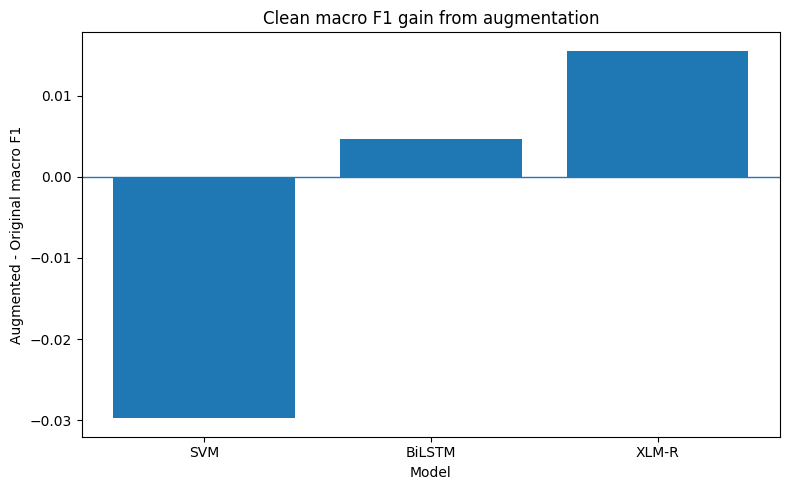

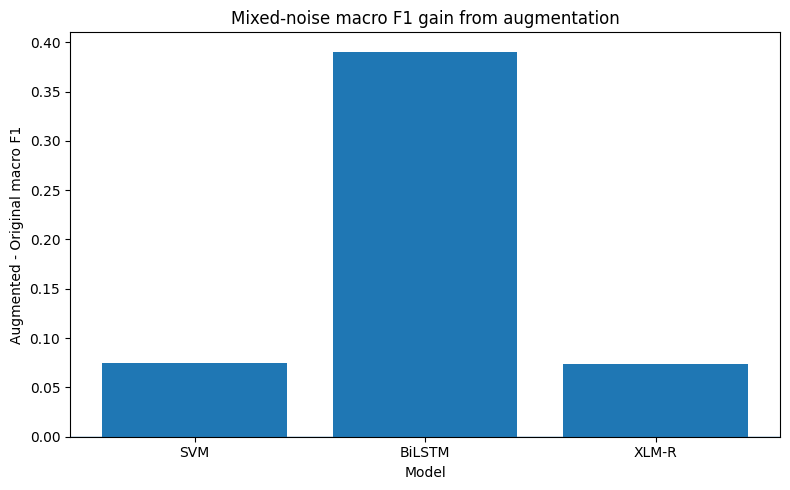

In [26]:
# 23. Final comparison figures
plot_gain = gain_df.dropna(subset=["clean_macro_f1_gain"]).copy()
if not plot_gain.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(plot_gain["model"], plot_gain["clean_macro_f1_gain"])
    plt.axhline(0, linewidth=1)
    plt.title("Clean macro F1 gain from augmentation")
    plt.xlabel("Model")
    plt.ylabel("Augmented - Original macro F1")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "augmentation_clean_macro_f1_gain_by_model.png", dpi=180)
    plt.show()

plot_mixed = gain_df.dropna(subset=["mixed_noise_macro_f1_gain"]).copy()
if not plot_mixed.empty:
    plt.figure(figsize=(8, 5))
    plt.bar(plot_mixed["model"], plot_mixed["mixed_noise_macro_f1_gain"])
    plt.axhline(0, linewidth=1)
    plt.title("Mixed-noise macro F1 gain from augmentation")
    plt.xlabel("Model")
    plt.ylabel("Augmented - Original macro F1")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "augmentation_mixed_noise_macro_f1_gain_by_model.png", dpi=180)
    plt.show()

In [27]:
# 24. Final checklist
expected_outputs = [
    RESULTS_DIR / "bilstm_robustness_metrics.csv",
    RESULTS_DIR / "bilstm_robustness_predictions.csv",
    RESULTS_DIR / "svm_vs_bilstm_error_comparison.csv",
    RESULTS_DIR / "bilstm_failure_summary.csv",
    RESULTS_DIR / "bilstm_failure_examples.csv",
    RESULTS_DIR / "phobert_augmented_training_log.csv",
    RESULTS_DIR / "phobert_augmented_robustness_metrics.csv",
    RESULTS_DIR / "phobert_augmented_robustness_predictions.csv",
    RESULTS_DIR / "augmentation_all_models_metrics.csv",
    RESULTS_DIR / "augmentation_all_models_comparison.csv",
    RESULTS_DIR / "augmentation_gain_by_model.csv",
    MODELS_DIR / "bilstm_original_recheck" / "bilstm_best.pt",
    MODELS_DIR / "bilstm_augmented_mixed" / "bilstm_best.pt",
    MODELS_DIR / "phobert_augmented_mixed",
]

check_df = pd.DataFrame({
    "path": [str(p) for p in expected_outputs],
    "exists": [p.exists() for p in expected_outputs],
})
check_df.to_csv(RESULTS_DIR / "note08b_output_checklist.csv", index=False)
print(check_df)

if not check_df["exists"].all():
    missing = check_df[~check_df["exists"]]["path"].tolist()
    print("Missing outputs:", missing)
else:
    print("All expected Note 8b final outputs exist.")

                                                 path  exists
0   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
1   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
2   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
3   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
4   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
5   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
6   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
7   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
8   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
9   /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
10  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
11  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
12  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
13  /content/drive/MyDrive/Deep/vietnamese-toxic-c...    True
All expected Note 8b final outputs exist.
